In [177]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

In [178]:
# Load Cleaned Dataset
df = pd.read_csv(r"C:\Users\earlc\Amdari\Week 2\nexora_care_flow\data\processed\cleaned_appointments.csv")

In [179]:
# Summary
total_rows = len(df)
total_cols = df.shape[1]
total_nulls = df.isnull().sum().sum()
print(
    f" Action Complete:\n"
    f"   - Dataset Loaded: {total_rows:,} records across {total_cols} columns\n"
    f"   - Data Hygiene Audit: {total_nulls} missing values (100% clean record set)"
)
df.head()

 Action Complete:
   - Dataset Loaded: 129,353 records across 15 columns
   - Data Hygiene Audit: 0 missing values (100% clean record set)


,AppointmentID,ClinicID,ClinicName,ClinicType,PatientID,ProviderID,AppointmentDateTime,AppointmentType,Status,BookingChannel,BookingLeadTimeDays,IsHoliday,HolidayName,SeasonFlag,ChronicConditionFlag
0,529385,2,Nexora Care - Lakeside,Multi-Specialty,103642,202,2024-01-01 08:00:00,New Patient,Completed,Online,2,True,New Year's Day,Flu Season,False
1,500000,1,Nexora Care - Riverside,Primary Care,101551,101,2024-01-01 08:30:00,New Patient,No-Show,Online,18,True,New Year's Day,Flu Season,False
2,500011,1,Nexora Care - Riverside,Primary Care,100260,104,2024-01-01 08:30:00,Follow-Up,Completed,Referral,4,True,New Year's Day,Flu Season,False
3,575066,3,Nexora Care - Downtown Express,Telehealth-Forward,104923,301,2024-01-01 09:45:00,Urgent,Completed,Online,0,True,New Year's Day,Flu Season,False
4,500008,1,Nexora Care - Riverside,Primary Care,101124,104,2024-01-01 09:45:00,Telehealth,Completed,Phone,2,True,New Year's Day,Flu Season,False


#### Datetime Conversion

In [180]:
# Convert AppointmentDateTime
dtype_before = df['AppointmentDateTime'].dtype
df['AppointmentDateTime'] = pd.to_datetime(df['AppointmentDateTime'])

# Summary
dtype_after = df['AppointmentDateTime'].dtype

print(
    f" Action Complete:\n"
    f"   - Target Column: 'AppointmentDateTime'\n"
    f"   - Type Conversion: Converted from '{dtype_before}' ➔ '{dtype_after}'\n"
)
df.head()


 Action Complete:
   - Target Column: 'AppointmentDateTime'
   - Type Conversion: Converted from 'str' ➔ 'datetime64[us]'



,AppointmentID,ClinicID,ClinicName,ClinicType,PatientID,ProviderID,AppointmentDateTime,AppointmentType,Status,BookingChannel,BookingLeadTimeDays,IsHoliday,HolidayName,SeasonFlag,ChronicConditionFlag
0,529385,2,Nexora Care - Lakeside,Multi-Specialty,103642,202,2024-01-01 08:00:00,New Patient,Completed,Online,2,True,New Year's Day,Flu Season,False
1,500000,1,Nexora Care - Riverside,Primary Care,101551,101,2024-01-01 08:30:00,New Patient,No-Show,Online,18,True,New Year's Day,Flu Season,False
2,500011,1,Nexora Care - Riverside,Primary Care,100260,104,2024-01-01 08:30:00,Follow-Up,Completed,Referral,4,True,New Year's Day,Flu Season,False
3,575066,3,Nexora Care - Downtown Express,Telehealth-Forward,104923,301,2024-01-01 09:45:00,Urgent,Completed,Online,0,True,New Year's Day,Flu Season,False
4,500008,1,Nexora Care - Riverside,Primary Care,101124,104,2024-01-01 09:45:00,Telehealth,Completed,Phone,2,True,New Year's Day,Flu Season,False


#### Extract Calendar Features

In [181]:
# Extract Date, Time, and Day of Week
# Extract `AppointmentDate`, `AppointmentTime`, and `DayOfWeek` from `AppointmentDateTime` to enable 
# granular day-of-week demand visualization and daily/weekly aggregations.

df['AppointmentDate'] = df['AppointmentDateTime'].dt.floor('D')
df['AppointmentTime'] = df['AppointmentDateTime'].dt.time
df['DayOfWeek'] = df['AppointmentDateTime'].dt.day_name()

# Summary
new_cols = ['AppointmentDate', 'AppointmentTime', 'DayOfWeek']
unique_days = df['DayOfWeek'].nunique()
days_list = df['DayOfWeek'].unique().tolist()

print(
    f" Action Complete:\n"
    f"   - Calendar Features Extracted ({len(new_cols)} columns): {', '.join(new_cols)}\n"
    f"   - Day-of-Week Coverage: {unique_days} unique days ({', '.join(days_list[:3])}...)\n"
    f"   - Updated Dataset Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns"
)
df[['AppointmentDateTime', 'AppointmentDate', 'AppointmentTime', 'DayOfWeek']].head()


 Action Complete:
   - Calendar Features Extracted (3 columns): AppointmentDate, AppointmentTime, DayOfWeek
   - Day-of-Week Coverage: 7 unique days (Monday, Tuesday, Wednesday...)
   - Updated Dataset Dimensions: 129,353 rows × 18 columns


,AppointmentDateTime,AppointmentDate,AppointmentTime,DayOfWeek
0,2024-01-01 08:00:00,2024-01-01,08:00:00,Monday
1,2024-01-01 08:30:00,2024-01-01,08:30:00,Monday
2,2024-01-01 08:30:00,2024-01-01,08:30:00,Monday
3,2024-01-01 09:45:00,2024-01-01,09:45:00,Monday
4,2024-01-01 09:45:00,2024-01-01,09:45:00,Monday


#### Daily Aggregation

In [182]:
# Daily Aggregation
daily_df = df.groupby(['ClinicID', 'ClinicName', 'AppointmentDate', 'DayOfWeek', 'HolidayName', 'IsHoliday']).agg(
    TotalScheduled=('AppointmentID', 'count')
).reset_index().sort_values(['ClinicID', 'AppointmentDate'])

out_daily_path = r"c:\Users\earlc\Amdari\Week 2\nexora_care_flow\data\processed\daily_clinic_appointments.csv"
daily_df.to_csv(out_daily_path, index=False)

# Summary
daily_rows = len(daily_df)
daily_cols = daily_df.shape[1]
avg_daily_appt = daily_df['TotalScheduled'].mean()
max_daily_appt = daily_df['TotalScheduled'].max()

print(
    f" Action Complete:\n"
    f"   - Aggregation Level: Daily totals per clinic\n"
    f"   - Daily Dataset Dimensions: {daily_rows:,} records × {daily_cols} columns\n"
    f"   - Volume Highlights: Mean = {avg_daily_appt:.1f} appts/day | Peak = {max_daily_appt} appts in a single day\n"
    f"   - Export Destination: '{out_daily_path}'"
)
daily_df.head()


 Action Complete:
   - Aggregation Level: Daily totals per clinic
   - Daily Dataset Dimensions: 2,457 records × 7 columns
   - Volume Highlights: Mean = 52.6 appts/day | Peak = 140 appts in a single day
   - Export Destination: 'c:\Users\earlc\Amdari\Week 2\nexora_care_flow\data\processed\daily_clinic_appointments.csv'


,ClinicID,ClinicName,AppointmentDate,DayOfWeek,HolidayName,IsHoliday,TotalScheduled
0,1,Nexora Care - Riverside,2024-01-01,Monday,New Year's Day,True,13
1,1,Nexora Care - Riverside,2024-01-02,Tuesday,Non-Holiday,False,75
2,1,Nexora Care - Riverside,2024-01-03,Wednesday,Non-Holiday,False,66
3,1,Nexora Care - Riverside,2024-01-04,Thursday,Non-Holiday,False,62
4,1,Nexora Care - Riverside,2024-01-05,Friday,Non-Holiday,False,36


#### Weekly Aggregation

In [183]:
# Weekly Aggregation (Monday Start)
df['WeekStart'] = df['AppointmentDate'].dt.to_period('W-SUN').dt.start_time

weekly_df = df.groupby(['ClinicID', 'ClinicName', 'WeekStart']).agg(
    TotalScheduled=('AppointmentID', 'count')
).reset_index().sort_values(['ClinicID', 'WeekStart'])

weekly_df['Year'] = weekly_df['WeekStart'].dt.year
weekly_df['Month'] = weekly_df['WeekStart'].dt.month

out_weekly_path = r"c:\Users\earlc\Amdari\Week 2\nexora_care_flow\data\processed\weekly_clinic_appointments.csv"
weekly_df.to_csv(out_weekly_path, index=False)

# Summary
weekly_rows = len(weekly_df)
weekly_cols = weekly_df.shape[1]
avg_weekly_appt = weekly_df['TotalScheduled'].mean()
max_weekly_appt = weekly_df['TotalScheduled'].max()

print(
    f" Action Complete:\n"
    f"   - Aggregation Level: Weekly totals (Monday start) per clinic\n"
    f"   - Weekly Dataset Dimensions: {weekly_rows:,} records × {weekly_cols} columns\n"
    f"   - Volume Highlights: Mean = {avg_weekly_appt:.1f} appts/week | Peak = {max_weekly_appt} appts in a week\n"
    f"   - Export Destination: '{out_weekly_path}'"
)
weekly_df.head()


 Action Complete:
   - Aggregation Level: Weekly totals (Monday start) per clinic
   - Weekly Dataset Dimensions: 395 records × 6 columns
   - Volume Highlights: Mean = 327.5 appts/week | Peak = 609 appts in a week
   - Export Destination: 'c:\Users\earlc\Amdari\Week 2\nexora_care_flow\data\processed\weekly_clinic_appointments.csv'


,ClinicID,ClinicName,WeekStart,TotalScheduled,Year,Month
0,1,Nexora Care - Riverside,2024-01-01,269,2024,1
1,1,Nexora Care - Riverside,2024-01-08,316,2024,1
2,1,Nexora Care - Riverside,2024-01-15,261,2024,1
3,1,Nexora Care - Riverside,2024-01-22,284,2024,1
4,1,Nexora Care - Riverside,2024-01-29,283,2024,1


#### Quick Summary Statistics

In [184]:
# Summary Statistics
print("=== Daily Summary ===")
print(daily_df[['TotalScheduled']].describe())

print("\n=== Weekly Summary ===")
print(weekly_df[['TotalScheduled']].describe())

# Summary
daily_mean = daily_df['TotalScheduled'].mean()
daily_median = daily_df['TotalScheduled'].median()
daily_std = daily_df['TotalScheduled'].std()

weekly_mean = weekly_df['TotalScheduled'].mean()
weekly_median = weekly_df['TotalScheduled'].median()
weekly_std = weekly_df['TotalScheduled'].std()

print(
    f"\n Action Complete:\n"
    f"   - Daily Scheduled Volume: Mean = {daily_mean:.2f} | Median = {daily_median:.0f} | Std Dev = {daily_std:.2f}\n"
    f"   - Weekly Scheduled Volume: Mean = {weekly_mean:.2f} | Median = {weekly_median:.0f} | Std Dev = {weekly_std:.2f}"
)


=== Daily Summary ===
       TotalScheduled
count     2457.000000
mean        52.646724
std         25.508297
min          1.000000
25%         34.000000
50%         51.000000
75%         71.000000
max        140.000000

=== Weekly Summary ===
       TotalScheduled
count      395.000000
mean       327.475949
std         95.817489
min         14.000000
25%        255.500000
50%        313.000000
75%        398.500000
max        609.000000

 Action Complete:
   - Daily Scheduled Volume: Mean = 52.65 | Median = 51 | Std Dev = 25.51
   - Weekly Scheduled Volume: Mean = 327.48 | Median = 313 | Std Dev = 95.82


#### Day of Week Demand Averages

Day-of-Week Average Daily Appointments per Clinic
DayOfWeek  Mean_Daily_Appointments   Std_Dev  Days_Count
   Monday                56.467005 24.765879         394
  Tuesday                64.340102 24.468104         394
Wednesday                61.398477 23.938345         394
 Thursday                58.925641 23.845089         390
   Friday                54.653846 20.514605         390
 Saturday                28.278772 13.020360         391
   Sunday                21.259615  6.332219         104

 Action Complete:
   - Busiest Operational Day: Tuesday (Average = 64.3 appts/day per clinic)
   - Lowest Demand Day: Sunday (Average = 21.3 appts/day per clinic)
   - Weekday Demand Surge: Tuesday demand exceeds Friday demand by +17.7%



C:\Users\earlc\AppData\Local\Temp\ipykernel_30756\1055567652.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=daily_df, x='DayOfWeek', y='TotalScheduled', order=dow_order, palette='Blues_r', ci=None)
C:\Users\earlc\AppData\Local\Temp\ipykernel_30756\1055567652.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=daily_df, x='DayOfWeek', y='TotalScheduled', order=dow_order, palette='Blues_r', ci=None)


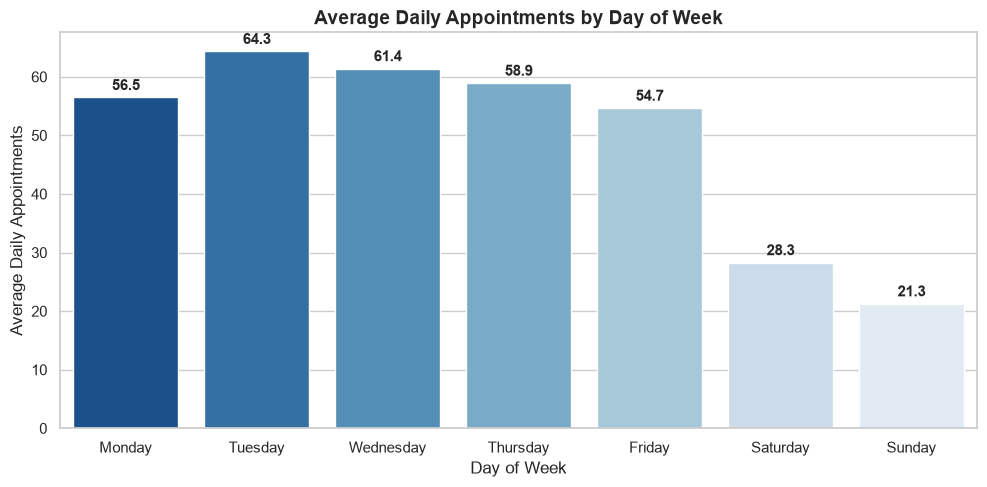

In [185]:
# Calculate & Plot Day-of-Week Demand Averages
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_summary = daily_df.groupby('DayOfWeek')['TotalScheduled'].agg(
    Mean_Daily_Appointments='mean',
    Std_Dev='std',
    Days_Count='count'
).reindex(dow_order).reset_index()

print("Day-of-Week Average Daily Appointments per Clinic")
print(dow_summary.to_string(index=False))

tue_mean = dow_summary.loc[dow_summary['DayOfWeek'] == 'Tuesday', 'Mean_Daily_Appointments'].values[0]
fri_mean = dow_summary.loc[dow_summary['DayOfWeek'] == 'Friday', 'Mean_Daily_Appointments'].values[0]
tue_surge_pct = ((tue_mean - fri_mean) / fri_mean) * 100

# Audit Summary
busiest_row = dow_summary.loc[dow_summary['Mean_Daily_Appointments'].idxmax()]
busiest_day = busiest_row['DayOfWeek']
busiest_avg = busiest_row['Mean_Daily_Appointments']

quietest_row = dow_summary.loc[dow_summary['Mean_Daily_Appointments'].idxmin()]
quietest_day = quietest_row['DayOfWeek']
quietest_avg = quietest_row['Mean_Daily_Appointments']

print(
    f"\n Action Complete:\n"
    f"   - Busiest Operational Day: {busiest_day} (Average = {busiest_avg:.1f} appts/day per clinic)\n"
    f"   - Lowest Demand Day: {quietest_day} (Average = {quietest_avg:.1f} appts/day per clinic)\n"
    f"   - Weekday Demand Surge: Tuesday demand exceeds Friday demand by +{tue_surge_pct:.1f}%\n"
)

# Plot Bar Chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=daily_df, x='DayOfWeek', y='TotalScheduled', order=dow_order, palette='Blues_r', ci=None)

# Show exact numbers on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 3), 
                textcoords='offset points')

plt.title('Average Daily Appointments by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Daily Appointments')
plt.tight_layout()
plt.show()


- Tuesday is the busiest weekday, averaging 64.3 appointments per clinic
- Surge Percentage: Tuesday is +17.7% busier than Friday `(64.3 - 54.7) / 54.7 = +17.7%`
- Mid-Week Heavy: Tuesdays (64.3), Wednesdays (61.4), and Thursdays (58.9) handle the highest appointment loads.
- Weekend Drop: Saturday (28.3) and Sunday (21.3) see sharp volume reductions due to reduced weekend operating hours.
- Staffing Advice: Shift rotas should maintain maximum clinician staffing on Tuesdays, Wednesdays, and Thursdays.

#### Total Volume & Percentage Share per Clinic

2-Year Total Appointments & Share per Clinic
 ClinicID                     ClinicName  TotalScheduled  Percentage_Share
        2         Nexora Care - Lakeside           45681         35.314991
        1        Nexora Care - Riverside           29382         22.714587
        4        Nexora Care - Hillcrest           29144         22.530595
        3 Nexora Care - Downtown Express           25146         19.439827

 Action Complete:
   - Highest Volume Clinic: 'Nexora Care - Lakeside' with 45,681 appts (35.3% share)
   - Lowest Volume Clinic: 'Nexora Care - Downtown Express' with 25,146 appts (19.4% share)
   - Enterprise Volume Total: 129,353 appointments analyzed across 4 clinics



C:\Users\earlc\AppData\Local\Temp\ipykernel_30756\842918187.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clinic_totals, y='ClinicName', x='TotalScheduled', palette='Blues_r', ax=ax2)


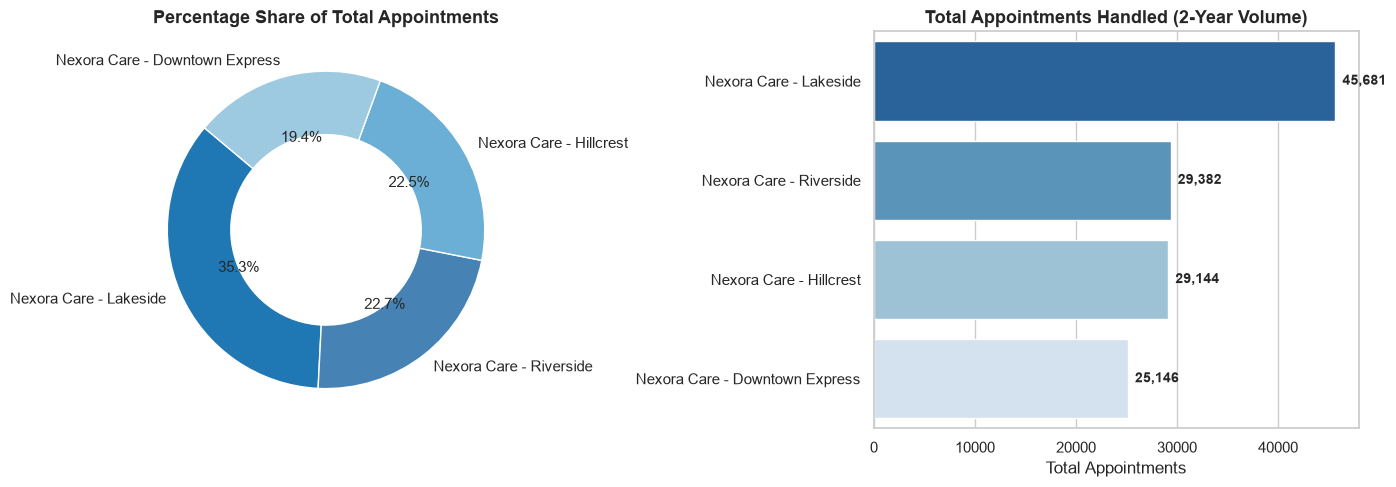

In [186]:
# Calculate Total Volume & Percentage Share per Clinic
clinic_totals = df.groupby(['ClinicID', 'ClinicName'])['AppointmentID'].count().reset_index()
clinic_totals.columns = ['ClinicID', 'ClinicName', 'TotalScheduled']

total_appts = clinic_totals['TotalScheduled'].sum()
clinic_totals['Percentage_Share'] = (clinic_totals['TotalScheduled'] / total_appts) * 100
clinic_totals = clinic_totals.sort_values(by='TotalScheduled', ascending=False)

print("2-Year Total Appointments & Share per Clinic")
print(clinic_totals.to_string(index=False))

# Audit Summary
busiest_clinic = clinic_totals.iloc[0]
busiest_name = busiest_clinic['ClinicName']
busiest_count = busiest_clinic['TotalScheduled']
busiest_share = busiest_clinic['Percentage_Share']

lowest_clinic = clinic_totals.iloc[-1]
lowest_name = lowest_clinic['ClinicName']
lowest_count = lowest_clinic['TotalScheduled']
lowest_share = lowest_clinic['Percentage_Share']

print(
    f"\n Action Complete:\n"
    f"   - Highest Volume Clinic: '{busiest_name}' with {busiest_count:,} appts ({busiest_share:.1f}% share)\n"
    f"   - Lowest Volume Clinic: '{lowest_name}' with {lowest_count:,} appts ({lowest_share:.1f}% share)\n"
    f"   - Enterprise Volume Total: {total_appts:,} appointments analyzed across {len(clinic_totals)} clinics\n"
)

# Plot Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Donut Chart
colors = ['#1f77b4', '#4682b4', '#6baed6', '#9ecae1']
ax1.pie(clinic_totals['TotalScheduled'], labels=clinic_totals['ClinicName'], autopct='%1.1f%%',
        startangle=140, colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))
ax1.set_title('Percentage Share of Total Appointments', fontsize=13, fontweight='bold')

# Bar Chart
sns.barplot(data=clinic_totals, y='ClinicName', x='TotalScheduled', palette='Blues_r', ax=ax2)
ax2.set_title('Total Appointments Handled (2-Year Volume)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Appointments')
ax2.set_ylabel('')

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width()):,}', 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), 
                 textcoords='offset points')

plt.tight_layout()
plt.show()


- Nexora Care - Lakeside is the largest clinic, handling 45,681 appointments, 35.3% of all appointments
- Nexora Care - Riverside: 29,382 appointments (22.7% share).
- Nexora Care - Hillcrest: 29,144 appointments (22.5% share).
- Nexora Care - Downtown Express**: 25,146 appointments (19.4% share).
- Staffing Advice: Lakeside requires the largest full-time clinician baseline (~435 appointments/week), while Downtown Express operates on a leaner core team (~239 appointments/week)

#### Weekly Volume Summary Statistics per Clinic

2-Year Weekly Appointment Volume Range per Clinic
 ClinicID                     ClinicName  Weekly_Mean  Weekly_Min  Weekly_Max   Std_Dev
        2         Nexora Care - Lakeside   435.057143         238         609 65.786927
        4        Nexora Care - Hillcrest   364.300000          14         541 74.127738
        1        Nexora Care - Riverside   279.828571         148         382 41.327598
        3 Nexora Care - Downtown Express   239.485714         111         363 41.653358

 Action Complete:
   - Peak Capacity Clinic: 'Nexora Care - Lakeside' averaging 435.1 appts/week (Single-week Max = 609)
   - Lowest Baseline Clinic: 'Nexora Care - Downtown Express' averaging 239.5 appts/week (Single-week Min = 111)
   - Timeframe Covered: 2 Full Operating Years (2024 – 2025)



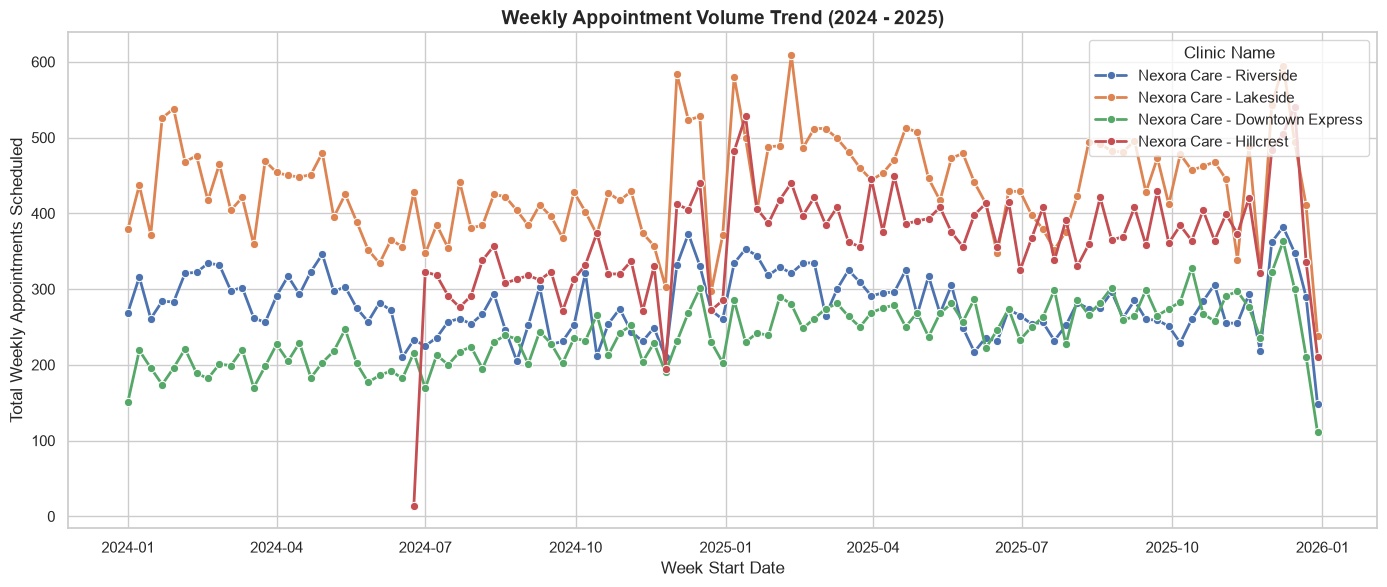

In [187]:
# Calculate Weekly Volume Summary Statistics per Clinic
weekly_summary = weekly_df.groupby(['ClinicID', 'ClinicName'])['TotalScheduled'].agg(
    Weekly_Mean='mean',
    Weekly_Min='min',
    Weekly_Max='max',
    Std_Dev='std'
).reset_index().sort_values(by='Weekly_Mean', ascending=False)

print("2-Year Weekly Appointment Volume Range per Clinic")
print(weekly_summary.to_string(index=False))

# Audit Summary
highest_weekly = weekly_summary.iloc[0]
highest_w_name = highest_weekly['ClinicName']
highest_w_mean = highest_weekly['Weekly_Mean']
highest_w_max = highest_weekly['Weekly_Max']

lowest_weekly = weekly_summary.iloc[-1]
lowest_w_name = lowest_weekly['ClinicName']
lowest_w_mean = lowest_weekly['Weekly_Mean']
lowest_w_min = lowest_weekly['Weekly_Min']

print(
    f"\n Action Complete:\n"
    f"   - Peak Capacity Clinic: '{highest_w_name}' averaging {highest_w_mean:.1f} appts/week (Single-week Max = {highest_w_max})\n"
    f"   - Lowest Baseline Clinic: '{lowest_w_name}' averaging {lowest_w_mean:.1f} appts/week (Single-week Min = {lowest_w_min})\n"
    f"   - Timeframe Covered: 2 Full Operating Years (2024 – 2025)\n"
)

# Plot Weekly Line Chart
plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_df, x='WeekStart', y='TotalScheduled', hue='ClinicName', marker='o', linewidth=2)

plt.title('Weekly Appointment Volume Trend (2024 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Total Weekly Appointments Scheduled')
plt.legend(title='Clinic Name', loc='upper right')
plt.tight_layout()
plt.show()


- Lakeside consistently operates at the highest volume (~435 weekly visits), Hillcrest second (~364), Riverside third (~280), and Downtown Express fourth (~239).
- All 4 clinics experience synchronized demand waves, proving that external macro factors (flu season, holidays) affect the entire health network simultaneously.
- Staffing Advice: Time-series models can leverage shared temporal and seasonal features across clinics.

Month-by-Month Average Weekly Appointments per Clinic
 Month Month_Name  Average_Weekly_Appointments
     1        Jan                   345.806452
     2        Feb                   360.642857
     3        Mar                   335.562500
     4        Apr                   345.161290
     5        May                   323.785714
     6        Jun                   294.515152
     7        Jul                   297.388889
     8        Aug                   327.812500
     9        Sep                   319.850000
    10        Oct                   330.437500
    11        Nov                   301.062500
    12        Dec                   352.850000
1. Summer Low (June, Month 6): 294.5 appointments/week (~295)
2. Winter Peak 1 (February, Month 2): 360.6 appointments/week (~361)
3. Winter Peak 2 (December, Month 12): 352.9 appointments/week (~353)
4. Surge vs Summer Low: (360.6 - 294.5) / 294.5 = +22.5%

 Action Complete:
   - Peak Seasonality Month: Feb (Average = 360.6 appts/we

C:\Users\earlc\AppData\Local\Temp\ipykernel_30756\1599773446.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=monthly_avg, x='Month_Name', y='Average_Weekly_Appointments', palette='Reds_d')


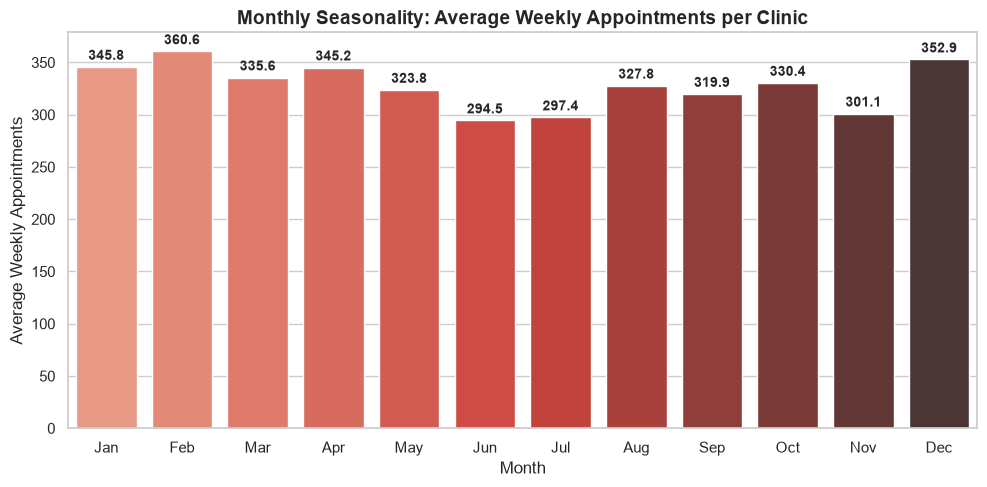

In [188]:
# Monthly Seasonality Aggregation
weekly_df['Month_Name'] = weekly_df['WeekStart'].dt.strftime('%b')
monthly_avg = weekly_df.groupby(['Month', 'Month_Name'])['TotalScheduled'].mean().reset_index()
monthly_avg.columns = ['Month', 'Month_Name', 'Average_Weekly_Appointments']

print("Month-by-Month Average Weekly Appointments per Clinic")
print(monthly_avg.to_string(index=False))

jun_mean = monthly_avg.loc[monthly_avg['Month'] == 6, 'Average_Weekly_Appointments'].values[0]
feb_mean = monthly_avg.loc[monthly_avg['Month'] == 2, 'Average_Weekly_Appointments'].values[0]
dec_mean = monthly_avg.loc[monthly_avg['Month'] == 12, 'Average_Weekly_Appointments'].values[0]
surge_vs_jun = ((feb_mean - jun_mean) / jun_mean) * 100

print(f"1. Summer Low (June, Month 6): {jun_mean:.1f} appointments/week (~{jun_mean:.0f})")
print(f"2. Winter Peak 1 (February, Month 2): {feb_mean:.1f} appointments/week (~{feb_mean:.0f})")
print(f"3. Winter Peak 2 (December, Month 12): {dec_mean:.1f} appointments/week (~{dec_mean:.0f})")
print(f"4. Surge vs Summer Low: ({feb_mean:.1f} - {jun_mean:.1f}) / {jun_mean:.1f} = +{surge_vs_jun:.1f}%")

# Audit Summary
peak_row = monthly_avg.loc[monthly_avg['Average_Weekly_Appointments'].idxmax()]
peak_month = peak_row['Month_Name']
peak_avg = peak_row['Average_Weekly_Appointments']

trough_row = monthly_avg.loc[monthly_avg['Average_Weekly_Appointments'].idxmin()]
trough_month = trough_row['Month_Name']
trough_avg = trough_row['Average_Weekly_Appointments']

print(
    f"\n Action Complete:\n"
    f"   - Peak Seasonality Month: {peak_month} (Average = {peak_avg:.1f} appts/week per clinic)\n"
    f"   - Summer Low Month: {trough_month} (Average = {trough_avg:.1f} appts/week per clinic)\n"
    f"   - Winter Flu Surge: {peak_month} peak volume is +{surge_vs_jun:.1f}% higher than the {trough_month} trough\n"
)

# Plot Bar Chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=monthly_avg, x='Month_Name', y='Average_Weekly_Appointments', palette='Reds_d')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), 
                textcoords='offset points')

plt.title('Monthly Seasonality: Average Weekly Appointments per Clinic', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Weekly Appointments')
plt.tight_layout()
plt.show()


- Summer Low (June): 295 average weekly appointments per clinic.
- Winter Peak (February & December): 361 (Feb) and 353 (Dec) weekly appointments per clinic (+22.5% increase over summer lows).
- Staffing Advice: Pre-hire temporary clinical staff or schedule voluntary overtime starting in early October ahead of the winter surge.


#### Lead Time Statistics per Clinic (Days)

Booking Lead Time Statistics per Clinic (Days)
 ClinicID                     ClinicName  Mean_Days  Median_Days  P25_Days  P75_Days
        3 Nexora Care - Downtown Express   9.434582          8.0       4.0      13.0
        2         Nexora Care - Lakeside   8.876929          7.0       3.0      12.0
        1        Nexora Care - Riverside   8.303825          6.0       2.0      12.0
        4        Nexora Care - Hillcrest   8.207212          6.0       2.0      12.0

Overall System Lead Time: Mean = 8.7 days, Median = 7.0 days

 Action Complete:
   - Longest Booking Horizon: 'Nexora Care - Downtown Express' (Mean = 9.4 days | Median = 8 days)
   - Shortest Booking Horizon: 'Nexora Care - Hillcrest' (Mean = 8.2 days | Median = 6 days)
   - System-Wide Lead Time Average: Mean = 8.7 days | Median = 7 days



C:\Users\earlc\AppData\Local\Temp\ipykernel_30756\3044084278.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ClinicName', y='BookingLeadTimeDays', palette='Set2')


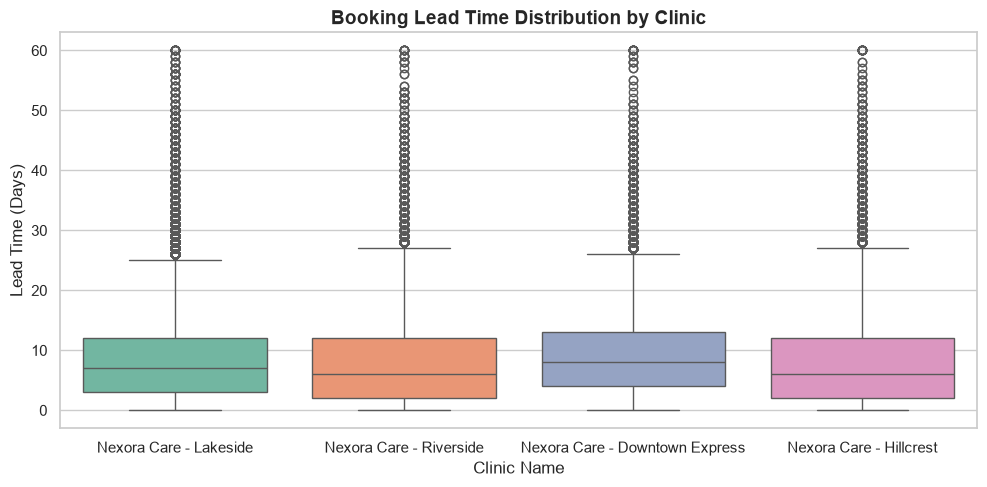

In [189]:
# How far in advance do patients book? (Lead Time)
lead_time_stats = df.groupby(['ClinicID', 'ClinicName'])['BookingLeadTimeDays'].agg(
    Mean_Days='mean',
    Median_Days='median',
    P25_Days=lambda x: x.quantile(0.25),
    P75_Days=lambda x: x.quantile(0.75)
).reset_index().sort_values(by='Mean_Days', ascending=False)

print("Booking Lead Time Statistics per Clinic (Days)")
print(lead_time_stats.to_string(index=False))

overall_mean = df['BookingLeadTimeDays'].mean()
overall_median = df['BookingLeadTimeDays'].median()
print(f"\nOverall System Lead Time: Mean = {overall_mean:.1f} days, Median = {overall_median:.1f} days")

# Audit Summary
longest_lead = lead_time_stats.iloc[0]
longest_name = longest_lead['ClinicName']
longest_mean = longest_lead['Mean_Days']

shortest_lead = lead_time_stats.iloc[-1]
shortest_name = shortest_lead['ClinicName']
shortest_mean = shortest_lead['Mean_Days']

print(
    f"\n Action Complete:\n"
    f"   - Longest Booking Horizon: '{longest_name}' (Mean = {longest_mean:.1f} days | Median = {longest_lead['Median_Days']:.0f} days)\n"
    f"   - Shortest Booking Horizon: '{shortest_name}' (Mean = {shortest_mean:.1f} days | Median = {shortest_lead['Median_Days']:.0f} days)\n"
    f"   - System-Wide Lead Time Average: Mean = {overall_mean:.1f} days | Median = {overall_median:.0f} days\n"
)

# Plot Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='ClinicName', y='BookingLeadTimeDays', palette='Set2')
plt.title('Booking Lead Time Distribution by Clinic', fontsize=14, fontweight='bold')
plt.xlabel('Clinic Name')
plt.ylabel('Lead Time (Days)')
plt.tight_layout()
plt.show()


- The average booking lead time is 8.7 days (Median = 7 days).
- Lead Time Range: Most appointments (25th to 75th percentile) are booked 2 to 12 days in advance
- Clinic Consistency: Downtown Express has a slightly higher average lead time (9.4 days), while Hillcrest (8.2 days) and Riverside (8.3 days) are slightly lower.
- Note: A 1-to-2 week lead time window allows clinic managers to finalize weekly shift rotas using actual advance bookings.

#### Holiday & Post-Holiday Demand Fluctuations

Q4 & January Weekly Appointment Volume Breakdown
 WeekStart  Average_Weekly_Volume_per_Clinic  Total_System_Volume
2024-01-01                        266.333333                  799
2024-01-08                        324.000000                  972
2024-01-15                        276.333333                  829
2024-01-22                        328.000000                  984
2024-01-29                        339.000000                 1017
2024-11-04                        315.500000                 1262
2024-11-11                        270.000000                 1080
2024-11-18                        291.250000                 1165
2024-11-25                        224.500000                  898
2024-12-02                        389.750000                 1559
2024-12-09                        392.500000                 1570
2024-12-16                        400.000000                 1600
2024-12-23                        267.750000                 1071
2024-12-30                 

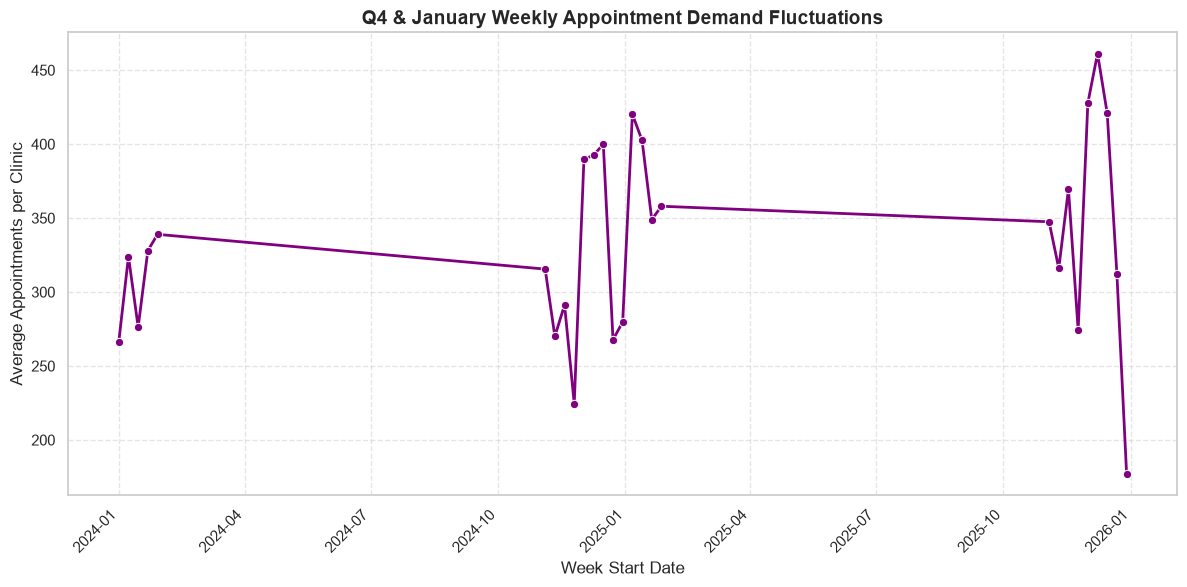

In [190]:
# Aggregate Weekly Scheduled Appointments across Q4 & January
q4_jan_weeks = weekly_df[weekly_df['Month'].isin([11, 12, 1])].copy()
q4_jan_summary = q4_jan_weeks.groupby('WeekStart').agg(
    Average_Weekly_Volume_per_Clinic=('TotalScheduled', 'mean'),
    Total_System_Volume=('TotalScheduled', 'sum')
).reset_index()

print("Q4 & January Weekly Appointment Volume Breakdown")
print(q4_jan_summary.to_string(index=False))

# Mathematical Derivations for Holiday Drops & Post-Holiday Rebounds
nov18_2024 = q4_jan_summary.loc[q4_jan_summary['WeekStart'] == '2024-11-18', 'Average_Weekly_Volume_per_Clinic'].values[0]
nov25_2024 = q4_jan_summary.loc[q4_jan_summary['WeekStart'] == '2024-11-25', 'Average_Weekly_Volume_per_Clinic'].values[0]
t_drop_2024 = ((nov25_2024 - nov18_2024) / nov18_2024) * 100

nov17_2025 = q4_jan_summary.loc[q4_jan_summary['WeekStart'] == '2025-11-17', 'Average_Weekly_Volume_per_Clinic'].values[0]
nov24_2025 = q4_jan_summary.loc[q4_jan_summary['WeekStart'] == '2025-11-24', 'Average_Weekly_Volume_per_Clinic'].values[0]
t_drop_2025 = ((nov24_2025 - nov17_2025) / nov17_2025) * 100

dec16_2024 = q4_jan_summary.loc[q4_jan_summary['WeekStart'] == '2024-12-16', 'Average_Weekly_Volume_per_Clinic'].values[0]
dec23_2024 = q4_jan_summary.loc[q4_jan_summary['WeekStart'] == '2024-12-23', 'Average_Weekly_Volume_per_Clinic'].values[0]
c_drop_2024 = ((dec23_2024 - dec16_2024) / dec16_2024) * 100

dec08_2025 = q4_jan_summary.loc[q4_jan_summary['WeekStart'] == '2025-12-08', 'Average_Weekly_Volume_per_Clinic'].values[0]
dec29_2025 = q4_jan_summary.loc[q4_jan_summary['WeekStart'] == '2025-12-29', 'Average_Weekly_Volume_per_Clinic'].values[0]
c_drop_2025 = ((dec29_2025 - dec08_2025) / dec08_2025) * 100

jan06_2025 = q4_jan_summary.loc[q4_jan_summary['WeekStart'] == '2025-01-06', 'Average_Weekly_Volume_per_Clinic'].values[0]
rebound_2024 = ((jan06_2025 - dec23_2024) / dec23_2024) * 100
rebound_2025 = ((jan06_2025 - dec29_2025) / dec29_2025) * 100

print(f"1. 2024 Thanksgiving Drop (Nov 18 -> Nov 25): ({nov25_2024:.1f} - {nov18_2024:.2f}) / {nov18_2024:.2f} = {t_drop_2024:.1f}% (~ -23%)")
print(f"2. 2025 Thanksgiving Drop (Nov 17 -> Nov 24): ({nov24_2025:.2f} - {nov17_2025:.1f}) / {nov17_2025:.1f} = {t_drop_2025:.1f}% (~ -26%)")
print(f"3. 2024 Christmas Drop (Dec 16 -> Dec 23):    ({dec23_2024:.2f} - {dec16_2024:.1f}) / {dec16_2024:.1f} = {c_drop_2024:.1f}% (~ -33%)")
print(f"4. 2025 Christmas Drop (Dec 08 -> Dec 29):    ({dec29_2025:.1f} - {dec08_2025:.2f}) / {dec08_2025:.2f} = {c_drop_2025:.1f}% (~ -62%)")
print(f"5. Jan 6 Rebound vs Dec 23 Christmas Week:     ({jan06_2025:.2f} - {dec23_2024:.2f}) / {dec23_2024:.2f} = +{rebound_2024:.1f}% (~ +57%)")
print(f"6. Jan 6 Rebound vs Dec 29 Christmas Low:      ({jan06_2025:.2f} - {dec29_2025:.1f}) / {dec29_2025:.1f} = +{rebound_2025:.1f}% (~ +137%)")

# Audit Summary
max_q4_row = q4_jan_summary.loc[q4_jan_summary['Total_System_Volume'].idxmax()]
min_q4_row = q4_jan_summary.loc[q4_jan_summary['Total_System_Volume'].idxmin()]

print(
    f"\n Action Complete:\n"
    f"   - Thanksgiving Impact: 2024 volume dropped by {t_drop_2024:.1f}%, 2025 volume dropped by {t_drop_2025:.1f}%\n"
    f"   - Christmas Impact: 2024 volume dropped by {c_drop_2024:.1f}%, 2025 volume dropped by {c_drop_2025:.1f}%\n"
    f"   - Post-Holiday January Rebound: Volume surged by +{rebound_2024:.1f}% following 2024 Christmas low and +{rebound_2025:.1f}% vs 2025 Christmas trough\n"
    f"   - Highest Q4/Jan System Week: Week of {max_q4_row['WeekStart']} ({max_q4_row['Total_System_Volume']:,} total appts)\n"
    f"   - Lowest Q4/Jan System Week: Week of {min_q4_row['WeekStart']} ({min_q4_row['Total_System_Volume']:,} total appts)\n"
)

# Plot Line Plot for Q4 & January Seasonality
plt.figure(figsize=(12, 6))
sns.lineplot(data=q4_jan_summary, x='WeekStart', y='Average_Weekly_Volume_per_Clinic', marker='o', color='purple', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Q4 & January Weekly Appointment Demand Fluctuations', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Average Appointments per Clinic')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


- Holiday weeks experience volume drops, followed by post-holiday surges.
- Thanksgiving Drop: Thanksgiving week drops to 225–274 appointments/clinic.
- Christmas Drop: Christmas week volume drops to 177–268 appointments/clinic.
- January Rebound: The first full week of January jumps back up to 420 appointments/clinic.
- Staffing Advice: Scale down shift coverage during Thanksgiving and Christmas weeks to prevent idle payroll waste, but return to full staffing capacity on January 2nd.